In [2]:
import pickle as pkl
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
import joblib



In [3]:
df = pd.read_csv("/Users/lienkim/Documents/Becode/immo-eliza-ml/data/cleaned/clean_dataframe.csv")
df.keys()

Index(['property_type', 'property_id', 'postcode', 'city', 'province',
       'address', 'latitude', 'longitude', 'price', 'property_state',
       'build_year', 'bedroom_count', 'livable_surface', 'total_surface',
       'garage', 'terrace', 'energy_consumption_kWh/m2/year', 'swimming_pool',
       'preschool_distance_m', 'train_station_distance_m',
       'supermarket_distance_m', 'nearest_city', 'nearest_city_distance_km',
       'price_per_m2'],
      dtype='str')

In [4]:


model = joblib.load("/Users/lienkim/Documents/Becode/immo-eliza-ml/models/linear_model.pkl")


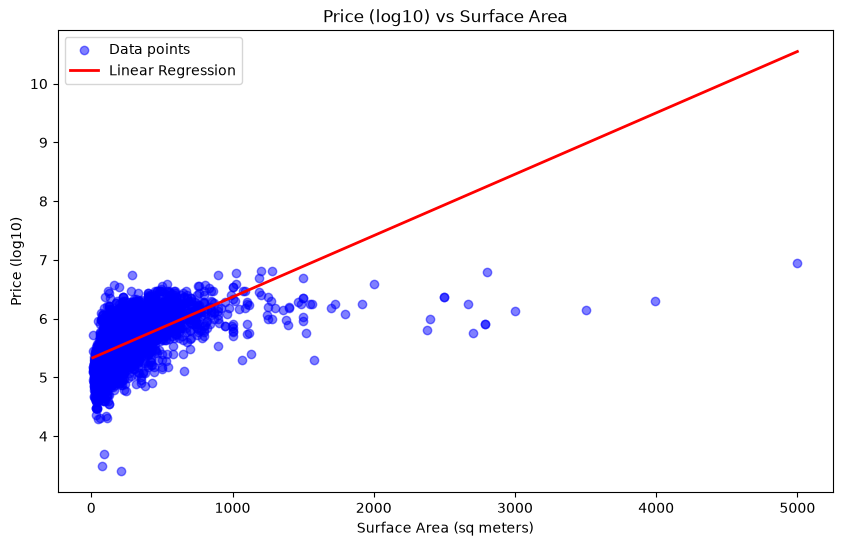

In [5]:
# plot linear regression model of price vs surface area
plt.figure(figsize=(10, 6))
plot_df = df[['livable_surface', 'price']].dropna()

x = plot_df['livable_surface'].to_numpy()
y = plot_df['price'].to_numpy()
y_log = np.log10(y)

slope, intercept = np.polyfit(x, y_log, 1)

order = np.argsort(x)
x_sorted = x[order]
y_line_log = slope * x_sorted + intercept

plt.scatter(x, y_log, color='blue', alpha=0.5, label='Data points')
plt.plot(
  x_sorted,
  y_line_log,
  color='red',
  linewidth=2,
  label='Linear Regression'
)
plt.title('Price (log10) vs Surface Area')
plt.xlabel('Surface Area (sq meters)')
plt.ylabel('Price (log10)')
plt.legend()
plt.show()

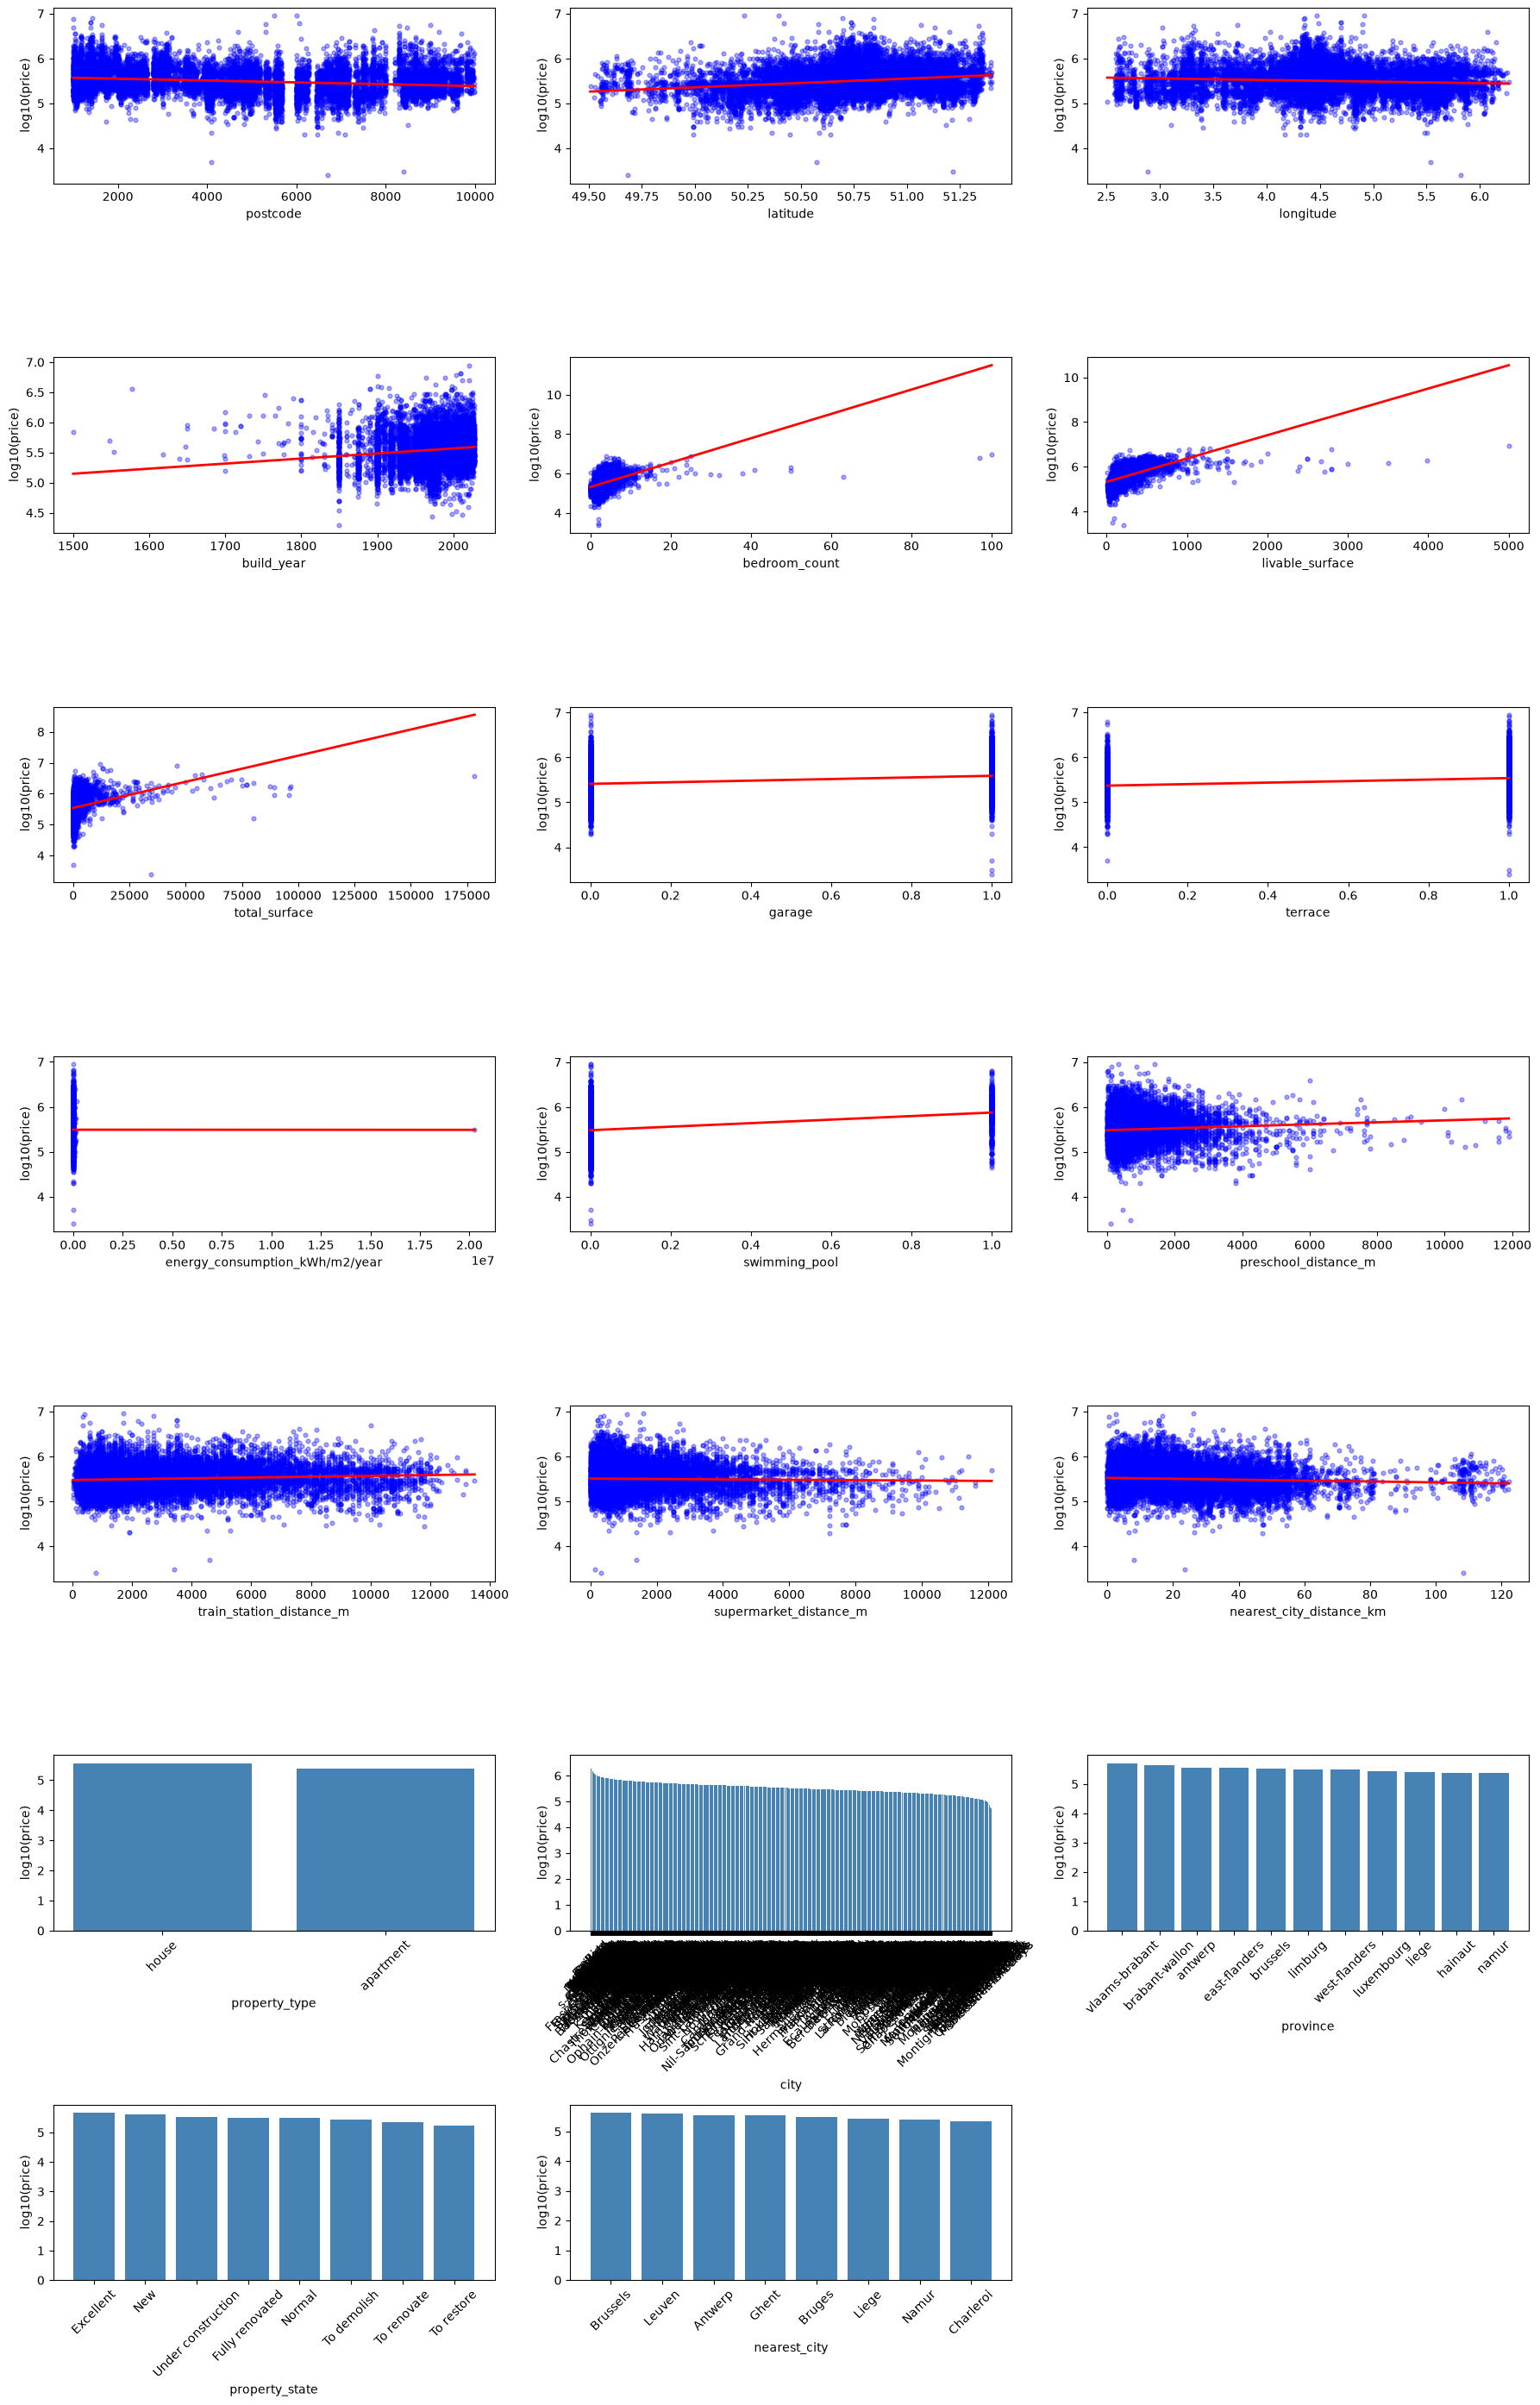

<Figure size 640x480 with 0 Axes>

In [6]:
preprocessor = model.named_steps['preprocessor']
numeric_features = list(preprocessor.transformers_[0][2])
categorical_features = list(preprocessor.transformers_[1][2])
features = numeric_features + categorical_features

# Keep only features present in df
valid_features = [f for f in features if f in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(valid_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).ravel()

for ax, feature in zip(axes, valid_features):
  plot_df = df[[feature, 'price']].dropna()
  plot_df = plot_df[plot_df['price'] > 0].copy()

  if plot_df.empty:
    ax.axis('off')
    continue

  plot_df['price'] = np.log10(plot_df['price'])

  if feature in numeric_features:
    x = plot_df[feature].to_numpy()
    y = plot_df['price'].to_numpy()

    ax.scatter(x, y, color='blue', alpha=0.35, s=12)

    if len(plot_df) > 1:
      slope, intercept = np.polyfit(x, y, 1)
      order = np.argsort(x)
      x_sorted = x[order]
      ax.plot(x_sorted, slope * x_sorted + intercept, color='red', linewidth=2)
  else:
    means = plot_df.groupby(feature)['price'].mean().sort_values(ascending=False)
    ax.bar(means.index.astype(str), means.values, color='steelblue')
    ax.tick_params(axis='x', rotation=45)

  ax.set_xlabel(feature)
  ax.set_ylabel('log10(price)')

# Hide any extra empty axes
for ax in axes[len(valid_features):]:
  ax.axis('off')

plt.tight_layout()
plt.show()
plt.savefig("/Users/lienkim/Documents/Becode/immo-eliza-ml/dev/plots/feature_price_relationships.png", dpi=300)
